In [1]:
import matplotlib.pyplot as plt
import numpy as np

/tmp/ipykernel_9796/520779062.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(p[0], p[1], "ro", color="blue")


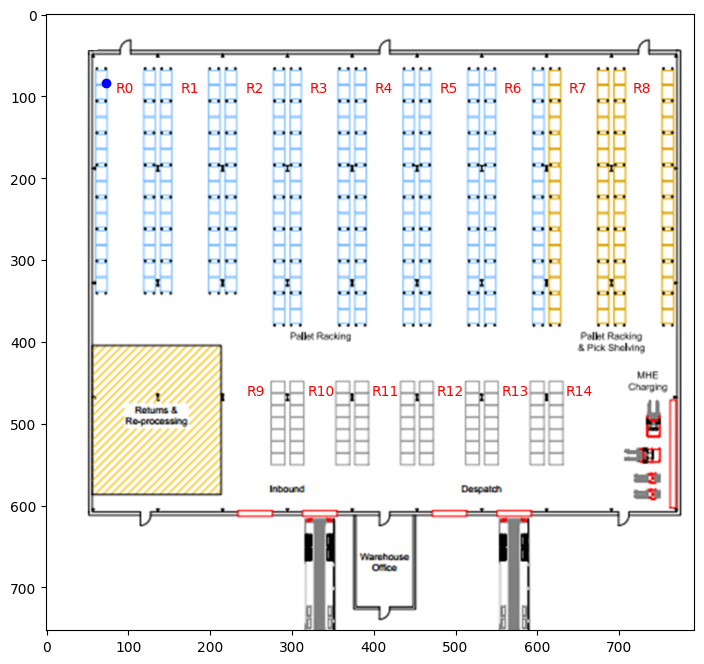

In [39]:
img = plt.imread("Layout/warehouse-layout_clear.png")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)

rows_text = [
    [85, 90],
]
for i in range(1,9):
    rows_text.append([85 + i * 79, 90])
rows_text.append([245,460])
for i in range(1,6):
    rows_text.append([240 + i * 79, 460])

for nr, row in enumerate(rows_text):
    ax.text(row[0], row[1], f"R{nr}", fontsize=10, color="red", ha="left", va="center")

locations_points = [
    [73,83]
]
for p in locations_points:
    ax.plot(p[0], p[1], "ro", color="blue")

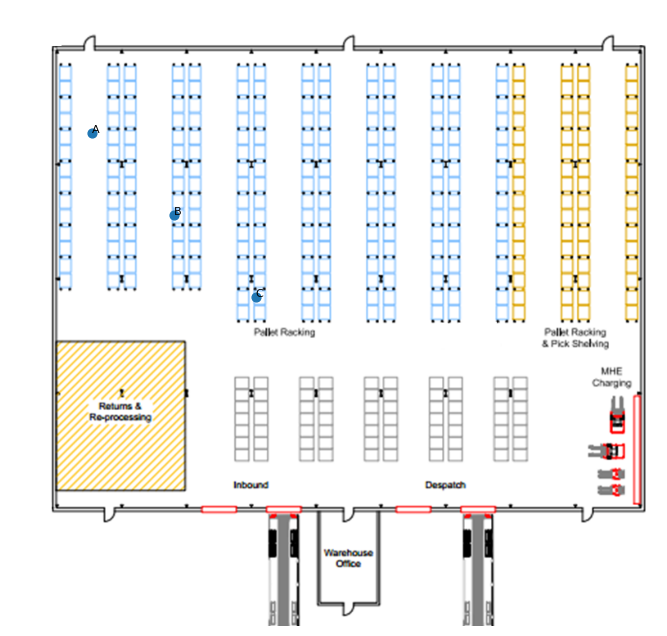

In [ ]:
img = plt.imread("Layout/warehouse-layout_clear.png")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)

# example points in image coordinates
xs = [100, 200, 300]
ys = [150, 250, 350]

ax.scatter(xs, ys, s=40)
for x, y, label in zip(xs, ys, ["A", "B", "C"]):
    ax.text(x, y, label, fontsize=8)

ax.axis("off")
plt.show()

In [9]:
img.shape

(753, 792, 4)

In [1]:
import compute_route
import importlib


In [2]:
importlib.reload(compute_route)
from compute_route import *

In [3]:
graph = load_graph('./map.json')
route_table = SingleRoute(graph, "Entrance")

In [4]:
graph

{'Entrance': {'Aisle_A': 4, 'Aisle_B': 2},
 'Aisle_A': {'Entrance': 4, 'Shelf_1': 5, 'Shelf_2': 10, 'Shelf_3': 2},
 'Aisle_B': {'Entrance': 2, 'Shelf_2': 3, 'Packing': 7},
 'Shelf_1': {'Aisle_A': 5, 'Packing': 6},
 'Shelf_2': {'Aisle_A': 10, 'Aisle_B': 3, 'Packing': 2},
 'Packing': {'Aisle_B': 7, 'Shelf_1': 6, 'Shelf_2': 2, 'Shelf_3': 4},
 'Shelf_3': {'Aisle_A': 2, 'Packing': 4}}

In [5]:
route_table.get_route("Shelf_1")

{'distance': 9, 'path': ['Entrance', 'Aisle_A', 'Shelf_1']}

In [6]:
dist = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

cost, tour = held_karp_with_path(dist, start=0)

print("Best cost:", cost)
print("Best tour:", tour)

Best cost: 80
Best tour: [0, 2, 3, 1, 0]


In [7]:
nodes = ["Entrance", "Shelf_1", "Shelf_2", "Shelf_3"]
named_tour = [nodes[i] for i in tour]
named_tour

['Entrance', 'Shelf_2', 'Shelf_3', 'Shelf_1', 'Entrance']

In [8]:
route_with_stops(graph, ["Entrance", "Shelf_1", "Shelf_2", "Shelf_3"])

{'distance': 26,
 'path': ['Entrance',
  'Aisle_A',
  'Shelf_3',
  'Aisle_A',
  'Shelf_1',
  'Packing',
  'Shelf_2',
  'Aisle_B',
  'Entrance']}

In [9]:
route_with_stops(graph, ["Entrance"])

{'distance': 0, 'path': ['Entrance']}

In [10]:
route_with_stops(graph, ["Entrance", "Shelf_3"])

{'distance': 12,
 'path': ['Entrance', 'Aisle_A', 'Shelf_3', 'Aisle_A', 'Entrance']}

In [11]:
route_cache.cache

OrderedDict([('Shelf_1', <compute_route.SingleRoute at 0x7d45edcd8770>),
             ('Shelf_2', <compute_route.SingleRoute at 0x7d45edcd9310>),
             ('Entrance', <compute_route.SingleRoute at 0x7d45edcb7a10>),
             ('Shelf_3', <compute_route.SingleRoute at 0x7d45edcd92b0>)])